<a href="https://colab.research.google.com/github/ankush07das/Digital-Image-Watermarking-using-discrete-wavelet-transform/blob/main/Comparison%20Haar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pillow
!pip install PyWavelets
import pywt
import numpy as np
from PIL import Image,ImageEnhance
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [2]:
original_image_path = '/content/image.jpeg'  # Update with correct path
watermark_image_path = '/content/watermarktobe-removebg-preview.png'  # Update with correct path
watermarked_image_path = '/content/watermarked_image.png'

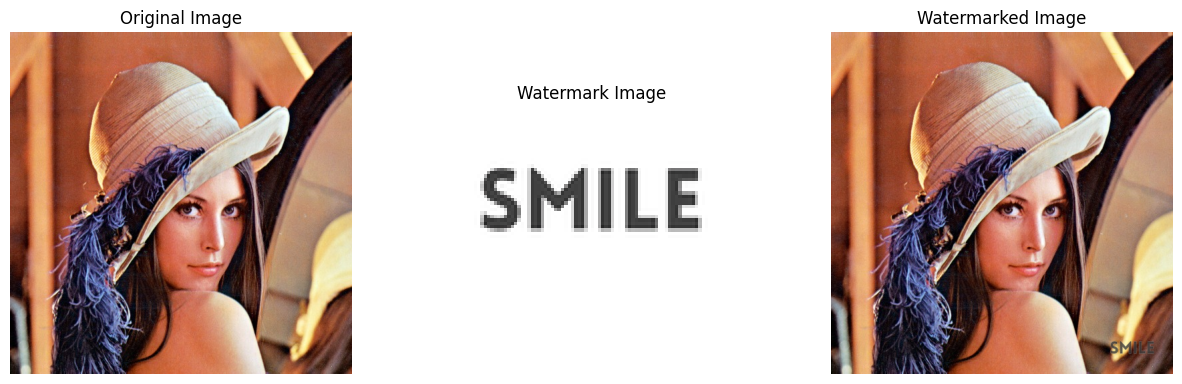

In [4]:
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt


original_image = Image.open(original_image_path).convert("RGBA")
watermark_image = Image.open(watermark_image_path).convert("RGBA")

# Set opacity level
opacity = 0.75

# Split image into RGB and Alpha channels
r, g, b, a = watermark_image.split()

# Enhance the Alpha channel
alpha_enhancer = ImageEnhance.Brightness(a)
a = alpha_enhancer.enhance(opacity)  # Reduce opacity

# Merge channels back
watermark_image = Image.merge("RGBA", (r, g, b, a))

# Resize watermark (optional)
width, height = original_image.size
watermark_width = int(width * 0.2)
watermark_height = int((watermark_width / watermark_image.width) * watermark_image.height)
watermark_image = watermark_image.resize((watermark_width, watermark_height), Image.Resampling.LANCZOS)

# Set watermark position (bottom-right)
watermark_position = (width - watermark_width - 10, height - watermark_height - 10)

# Create a copy of the original image to apply watermark
watermarked_image = original_image.copy()
watermarked_image.paste(watermark_image, watermark_position, watermark_image)

# Save the resulting image
output_path = "watermarked_image.png"
watermarked_image.save(output_path)

# Display all three images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(original_image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(watermark_image)
ax[1].set_title("Watermark Image")
ax[1].axis("off")

ax[2].imshow(watermarked_image)
ax[2].set_title("Watermarked Image")
ax[2].axis("off")

plt.show()

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths (use your existing paths here)
original_image_path = "/content/image.jpeg"
watermark_image_path = "/content/watermark_image.jpg"

# Load original image and watermark (watermark as grayscale)
original = cv2.imread(original_image_path)
watermark = cv2.imread(watermark_image_path, cv2.IMREAD_GRAYSCALE)

# Resize watermark to match original image
watermark = cv2.resize(watermark, (original.shape[1], original.shape[0]))

# Opacity level
alpha = 0.2

# Split original into channels
b, g, r = cv2.split(original)

# Blend watermark only with blue channel
b_watermarked = cv2.addWeighted(b.astype(np.float32), 1 - alpha, watermark.astype(np.float32), alpha, 0).astype(np.uint8)

# Merge channels back
watermarked = cv2.merge((b_watermarked, g, r))

# Save watermarked image
cv2.imwrite("/content/watermarked_image.png", watermarked)


True

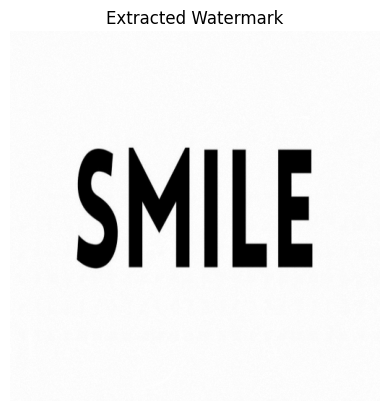

In [6]:
# Load both original and watermarked images
original = cv2.imread(original_image_path)
watermarked = cv2.imread("/content/watermarked_image.png")

# Split blue channels
b_orig, _, _ = cv2.split(original)
b_water, _, _ = cv2.split(watermarked)

# Extract watermark from the blue channel
extracted = ((b_water.astype(np.float32) - (1 - alpha) * b_orig.astype(np.float32)) / alpha)
extracted = np.clip(extracted, 0, 255).astype(np.uint8)

# Show the extracted watermark
plt.imshow(extracted, cmap='gray')
plt.title("Extracted Watermark")
plt.axis("off")
plt.show()

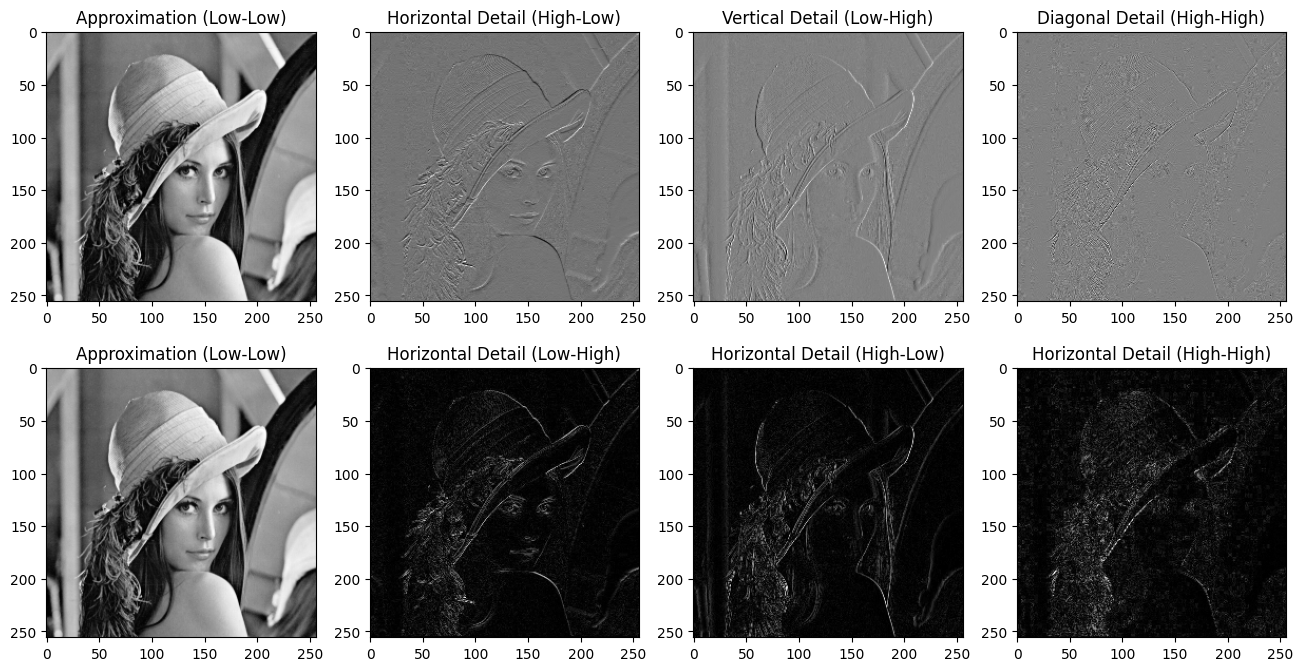

In [7]:
original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)

# Check if the image is loaded properly
if original_image is None:
    print("Error: Could not load the image. Please check the file path.")
else:
    # Perform Single-Level 2D Discrete Wavelet Transform
    coeffs2 = pywt.dwt2(original_image, 'haar')

    # Extract approximation and detail coefficients
    LL, (LH, HL, HH) = coeffs2

# Normalize function to scale values to 0-255 for visualization
def normalize_and_display(subband):
    subband = np.abs(subband)  # Take absolute values (ignore negative signs)
    subband = (subband / np.max(subband)) * 255  # Normalize to 0-255
    subband = np.uint8(subband)
    return subband

# Display the original image and transformed subbands
plt.figure(figsize=(16, 8))

plt.subplot(2, 4, 1)
plt.imshow(LL, cmap='gray')
plt.title('Approximation (Low-Low)')

plt.subplot(2, 4, 2)
plt.imshow(LH, cmap='gray')
plt.title('Horizontal Detail (High-Low)')

plt.subplot(2, 4, 3)
plt.imshow(HL, cmap='gray')
plt.title('Vertical Detail (Low-High)')

plt.subplot(2, 4, 4)
plt.imshow(HH, cmap='gray')
plt.title('Diagonal Detail (High-High)')

plt.subplot(2, 4, 5)
plt.imshow(normalize_and_display(LL), cmap='gray')
plt.title('Approximation (Low-Low)')

plt.subplot(2, 4, 6)
plt.imshow(normalize_and_display(LH), cmap='gray')
plt.title('Horizontal Detail (Low-High)')

plt.subplot(2, 4, 7)
plt.imshow(normalize_and_display(HL), cmap='gray')
plt.title('Horizontal Detail (High-Low)')

plt.subplot(2, 4, 8)
plt.imshow(normalize_and_display(HH), cmap='gray')
plt.title('Horizontal Detail (High-High)')

plt.show()

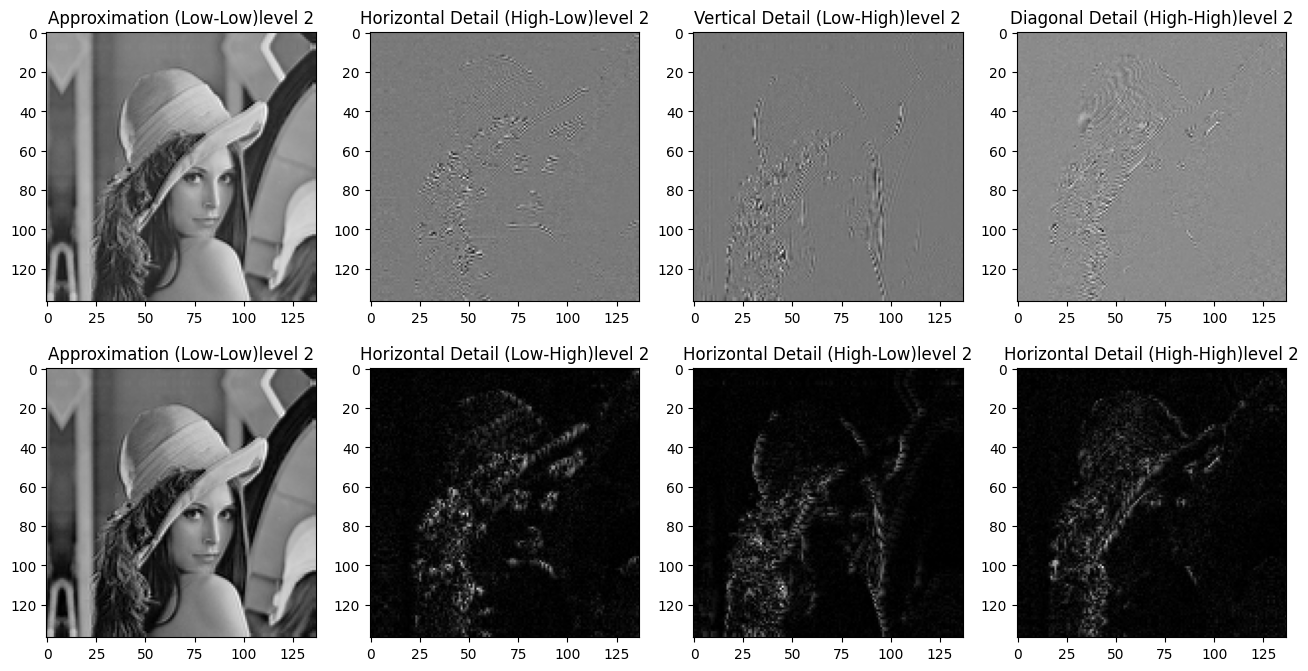

In [8]:
# Load the image in grayscale
original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)

# Check if the image is loaded properly
if original_image is None:
    print("Error: Could not load the image. Please check the file path.")
else:
    # Perform Single-Level 2D Discrete Wavelet Transform
    coeffs2 = pywt.dwt2(original_image, 'haar')

    # Extract approximation and detail coefficients
    LL, (LH, HL, HH) = coeffs2

    # Perform Second-Level DWT on LL using Daubechies (db10)
    coeffs3 = pywt.dwt2(LL, 'db10')
    LL1, (LH1, HL1, HH1) = coeffs3

# Normalize function to scale values to 0-255 for visualization
def normalize_and_display(subband):
    subband = np.abs(subband)  # Take absolute values (ignore negative signs)
    subband = (subband / np.max(subband)) * 255  # Normalize to 0-255
    subband = np.uint8(subband)
    return subband

# Display the original image and transformed subbands
plt.figure(figsize=(16, 8))

plt.subplot(2, 4, 1)
plt.imshow(LL1, cmap='gray')
plt.title('Approximation (Low-Low)level 2')

plt.subplot(2, 4, 2)
plt.imshow(LH1, cmap='gray')
plt.title('Horizontal Detail (High-Low)level 2')

plt.subplot(2, 4, 3)
plt.imshow(HL1, cmap='gray')
plt.title('Vertical Detail (Low-High)level 2')

plt.subplot(2, 4, 4)
plt.imshow(HH1, cmap='gray')
plt.title('Diagonal Detail (High-High)level 2')

plt.subplot(2, 4, 5)
plt.imshow(normalize_and_display(LL1), cmap='gray')
plt.title('Approximation (Low-Low)level 2')

plt.subplot(2, 4, 6)
plt.imshow(normalize_and_display(LH1), cmap='gray')
plt.title('Horizontal Detail (Low-High)level 2')

plt.subplot(2, 4, 7)
plt.imshow(normalize_and_display(HL1), cmap='gray')
plt.title('Horizontal Detail (High-Low)level 2')

plt.subplot(2, 4, 8)
plt.imshow(normalize_and_display(HH1), cmap='gray')
plt.title('Horizontal Detail (High-High)level 2')

plt.show()

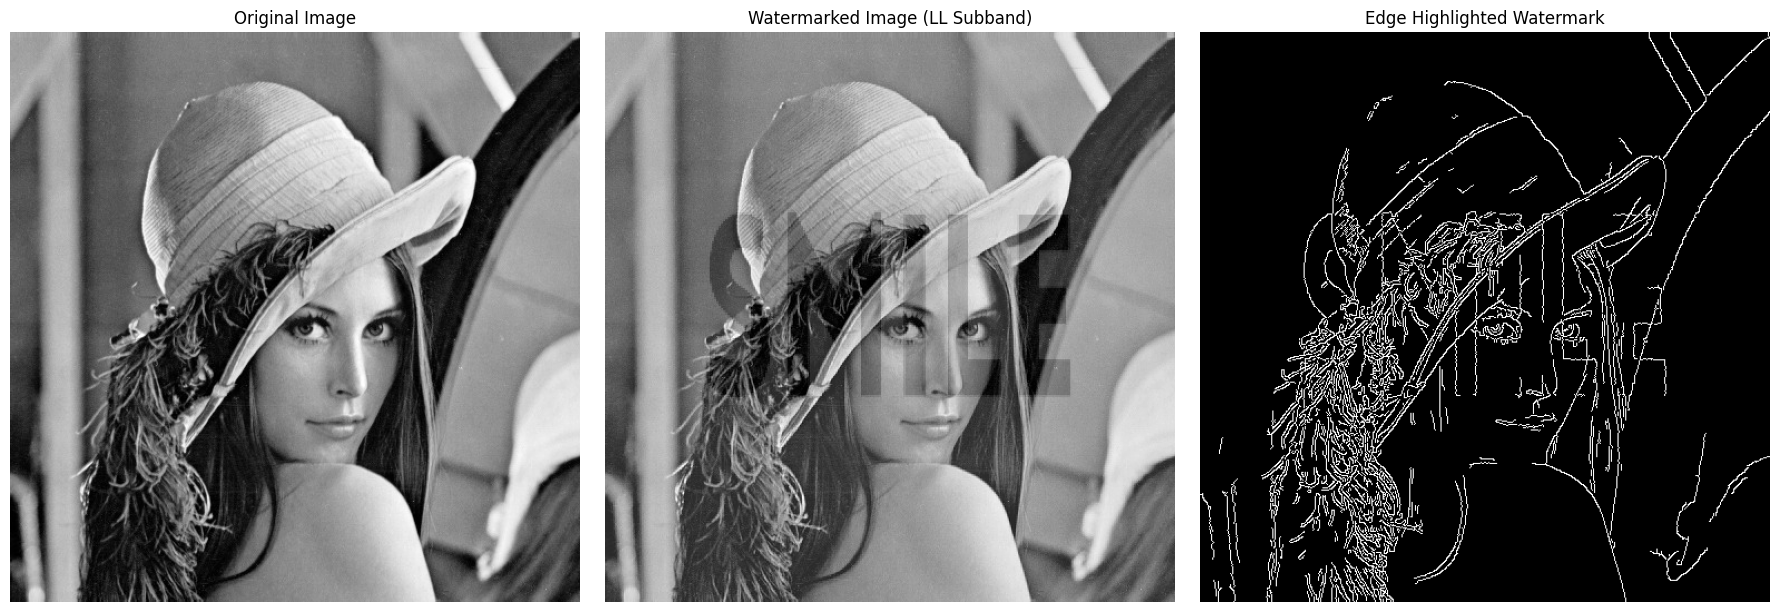

In [9]:


# Load the original image and watermark in grayscale
original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
watermark_image = cv2.imread(watermark_image_path, cv2.IMREAD_GRAYSCALE)

# Check if the image is loaded properly
if original_image is None:
    print("Error: Could not load the image. Please check the file path.")
else:
    # Perform Single-Level 2D Discrete Wavelet Transform
    coeffs2 = pywt.dwt2(original_image, 'haar')

    # Extract approximation and detail coefficients
    LL, (LH, HL, HH) = coeffs2

    # Resize watermark to match the LL subband size
    watermark_resized = cv2.resize(watermark_image, (LL.shape[1], LL.shape[0]))

    # Convert to float32 for blending
    LL_float = LL.astype(np.float32)
    watermark_float = watermark_resized.astype(np.float32)

    # Define opacity level
    alpha = 0.3  # Increased for better visibility

    # Blend watermark with LL subband
    LL_watermarked = ((1 - alpha) * LL_float + alpha * watermark_float).astype(np.float32)

    # Perform inverse DWT to reconstruct the image
    coeffs_watermarked = (LL_watermarked, (LH, HL, HH))
    watermarked_image = pywt.idwt2(coeffs_watermarked, 'haar')
    watermarked_image = np.clip(watermarked_image, 0, 255).astype(np.uint8)

    # Save watermarked image with watermark embedded in LL subband
    cv2.imwrite('/content/LL_watermarked_image.png', watermarked_image)

    # Generate edge-highlighted version (black background + embedded edges)
    edges = cv2.Canny(watermarked_image.astype(np.uint8), 100, 200)
    embedded_edges = np.zeros_like(watermarked_image)
    embedded_edges[edges > 0] = 255

    # Display original image, watermarked image, and edge-highlighted version
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(original_image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(watermarked_image, cmap='gray')
    plt.title('Watermarked Image (LL Subband)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(embedded_edges, cmap='gray')
    plt.title('Edge Highlighted Watermark')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)
/usr/local/lib/python3.11/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


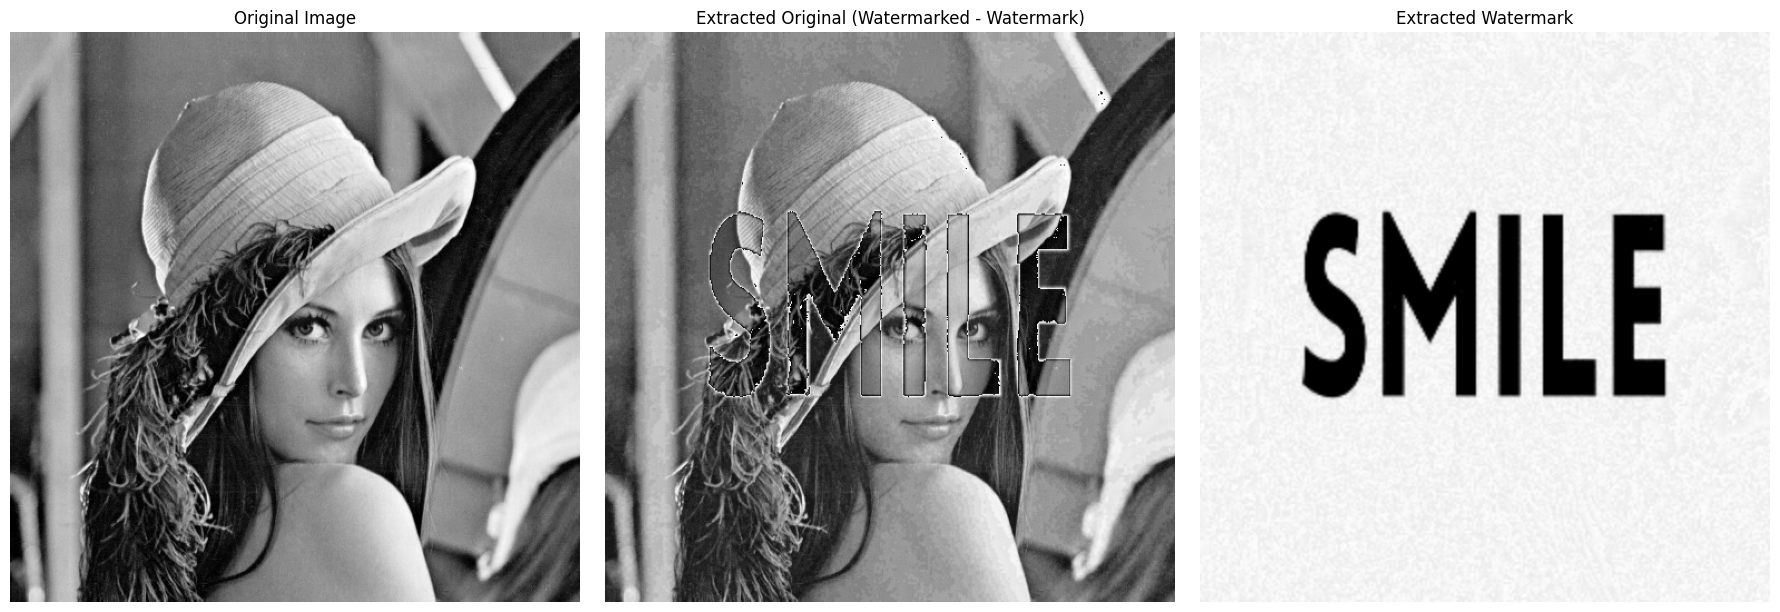


========= IMAGE QUALITY REPORT =========

[Original Image]
  MSE:  0.00
  PSNR: inf dB

[Extracted Original (Watermarked - Watermark)]
  MSE:  577.76
  PSNR: 20.51 dB

[Original Watermark]
  MSE:  0.00
  PSNR: inf dB

[Extracted Watermark]
  MSE:  178.23
  PSNR: 25.62 dB


In [10]:
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from sklearn.metrics import mean_squared_error

# Load paths
original_image_path = '/content/image.jpeg'
watermark_image_path = '/content/watermark_image.jpg'

# Load images in grayscale
original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
watermark_image = cv2.imread(watermark_image_path, cv2.IMREAD_GRAYSCALE)

# 1st Level DWT on original image
coeffs2 = pywt.dwt2(original_image, 'haar')
LL, (LH, HL, HH) = coeffs2

# Resize watermark to match LL size
watermark_resized = cv2.resize(watermark_image, (LL.shape[1], LL.shape[0]))

# Embed watermark into LL
alpha = 0.1
LL_embedded = ((1 - alpha) * LL + alpha * watermark_resized).astype(np.float32)

# Perform inverse DWT with modified LL to get the watermarked image
watermarked_image = pywt.idwt2((LL_embedded, (LH, HL, HH)), 'haar')
watermarked_image = np.clip(watermarked_image, 0, 255).astype(np.uint8)

# ======= Extraction Process =======
# DWT on watermarked image
coeffs2_wm = pywt.dwt2(watermarked_image, 'haar')
LL_wm, _ = coeffs2_wm

# Extract watermark by subtracting original LL from watermarked LL
extracted_watermark = ((LL_wm - (1 - alpha) * LL) / alpha)
extracted_watermark = np.clip(extracted_watermark, 0, 255).astype(np.uint8)

# Resize extracted watermark to match watermarked image size
extracted_watermark_resized = cv2.resize(extracted_watermark, watermarked_image.shape[::-1])

# Remove watermark from watermarked image to get the original image
extracted_original_image = watermarked_image - extracted_watermark_resized
extracted_original_image = np.clip(extracted_original_image, 0, 255).astype(np.uint8)

# Resize for comparison
resized_watermark = cv2.resize(watermark_image, extracted_watermark_resized.shape[::-1])
resized_original = cv2.resize(original_image, watermarked_image.shape[::-1])

# ========== METRICS ==========
# 1. Original image
mse_ori = mean_squared_error(original_image.flatten(), original_image.flatten())
psnr_ori = psnr(original_image, original_image)

# 2. Extracted original (watermarked image - watermark)
mse_extracted_ori = mean_squared_error(original_image.flatten(), extracted_original_image.flatten())
psnr_extracted_ori = psnr(original_image, extracted_original_image)

# 3. Original watermark
mse_wm = mean_squared_error(resized_watermark.flatten(), resized_watermark.flatten())
psnr_wm = psnr(resized_watermark, resized_watermark)

# 4. Extracted watermark
mse_extracted_wm = mean_squared_error(resized_watermark.flatten(), extracted_watermark_resized.flatten())
psnr_extracted_wm = psnr(resized_watermark, extracted_watermark_resized)

# ========== DISPLAY ==========
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(extracted_original_image, cmap='gray')
plt.title("Extracted Original (Watermarked - Watermark)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(extracted_watermark_resized, cmap='gray')
plt.title("Extracted Watermark")
plt.axis('off')

plt.tight_layout()
plt.show()

# ========== PRINT QUALITY REPORT ==========
print("\n========= IMAGE QUALITY REPORT =========")

print("\n[Original Image]")
print(f"  MSE:  {mse_ori:.2f}")
print(f"  PSNR: {psnr_ori:.2f} dB")

print("\n[Extracted Original (Watermarked - Watermark)]")
print(f"  MSE:  {mse_extracted_ori:.2f}")
print(f"  PSNR: {psnr_extracted_ori:.2f} dB")

print("\n[Original Watermark]")
print(f"  MSE:  {mse_wm:.2f}")
print(f"  PSNR: {psnr_wm:.2f} dB")

print("\n[Extracted Watermark]")
print(f"  MSE:  {mse_extracted_wm:.2f}")
print(f"  PSNR: {psnr_extracted_wm:.2f} dB")


Original Image:

MSE: 0.00: This indicates that there is no difference between the original image and itself (which is expected, as you are comparing it to itself).

PSNR: inf dB: The PSNR value is infinity, which signifies that the image is perfectly identical to itself, and there is no noise or distortion.

Extracted Original (Watermarked - Watermark):

MSE: 577.76: The Mean Squared Error (MSE) is a measure of the difference between the original image and the extracted original image (after subtracting the watermark). A lower MSE indicates higher similarity. This value is relatively high, meaning the extracted image still has significant differences from the original.

PSNR: 20.51 dB: The Peak Signal-to-Noise Ratio (PSNR) is a metric that measures the quality of the reconstructed image. In general, a PSNR value above 30 dB is considered high quality. A PSNR of 20.51 dB is relatively low, indicating that the extracted image (watermarked image minus the watermark) is of moderate quality, and the watermark removal is not perfect.

Original Watermark:

MSE: 0.00: Again, as with the original image, there is no difference between the original watermark and itself.

PSNR: inf dB: Perfect similarity with itself, no noise or distortion.

Extracted Watermark:

MSE: 178.23: The Mean Squared Error here indicates the difference between the original watermark and the extracted watermark. A higher MSE means the extracted watermark is different from the original watermark.

PSNR: 25.62 dB: This is a fairly decent value for watermark extraction. A PSNR of 25.62 dB indicates that the extracted watermark is reasonably close to the original, but there is some degradation due to the embedding process or the attack during extraction.

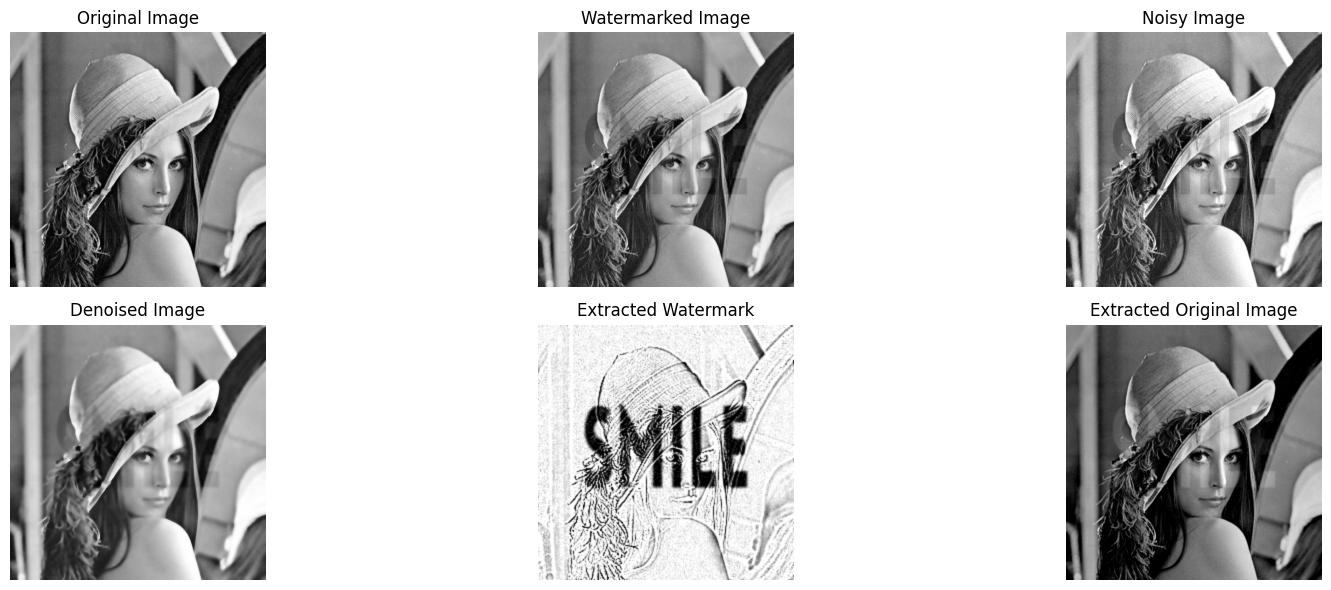

========= IMAGE QUALITY REPORT =========

[Original Image]
  MSE:  0.00
  PSNR: inf dB
  SNR : inf dB

[Watermarked vs Original]
  MSE:  583.64
  PSNR: 20.47 dB
  SNR : 14.85 dB

[Noisy vs Original]
  MSE:  106.61
  PSNR: 27.85 dB
  SNR : 14.90 dB

[Noisy vs Watermarked]
  MSE:  26.72
  PSNR: 33.86 dB
  SNR : 29.52 dB

[Denoised vs Original]
  MSE:  109.48
  PSNR: 27.74 dB
  SNR : 14.42 dB

[Denoised vs Watermarked]
  MSE:  103.66
  PSNR: 27.97 dB
  SNR : 23.63 dB

[Extracted Original vs Original]
  MSE:  141.94
  PSNR: 26.61 dB
  SNR : 15.01 dB

[Extracted Original vs Watermarked]
  MSE:  2272.68
  PSNR: 14.57 dB
  SNR : 10.22 dB

[Extracted Watermark vs Original Watermark]
  MSE:  58.41
  PSNR: 30.47 dB
  SNR : 12.29 dB



In [20]:
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Metrics Calculation Functions
# =========================

def mse(img1, img2):
    return np.mean((img1 - img2) ** 2)

def psnr(img1, img2):
    mse_val = mse(img1, img2)
    if mse_val == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse_val))

def get_snr(ref, test):
    signal_power = np.sum(ref.astype(np.float64) ** 2)
    noise_power = np.sum((ref.astype(np.float64) - test.astype(np.float64)) ** 2)
    if noise_power == 0:
        return float('inf')
    return 10 * np.log10(signal_power / noise_power)

def get_metrics(img1, img2):
    return mse(img1, img2), psnr(img1, img2), get_snr(img1, img2)

# =========================
# Load Images
# =========================

original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
watermark = cv2.imread(watermark_image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None or watermark is None:
    print("Error loading images. Check the paths.")
    exit()

# Resize watermark to match cA size
watermark = cv2.resize(watermark, (original_image.shape[1] // 2, original_image.shape[0] // 2))

# =========================
# Watermark Embedding
# =========================

coeffs2 = pywt.dwt2(original_image, 'haar')
cA, (cH, cV, cD) = coeffs2
alpha = 0.2
cA_watermarked = cA + alpha * watermark
watermarked_image = pywt.idwt2((cA_watermarked, (cH, cV, cD)), 'haar')

# =========================
# Add Noise and Denoise
# =========================

noise = np.random.normal(0, 5, watermarked_image.shape)
noisy_image = np.clip(watermarked_image + noise, 0, 255).astype(np.uint8)
denoised_image = cv2.bilateralFilter(noisy_image, 9, 75, 75)

# =========================
# Watermark Extraction
# =========================

coeffs_denoised = pywt.dwt2(denoised_image, 'haar')
cA_denoised, _ = coeffs_denoised
extracted_watermark = (cA_denoised - cA) / alpha
extracted_watermark = np.clip(extracted_watermark, 0, 255).astype(np.uint8)
extracted_watermark_resized = cv2.resize(extracted_watermark, (original_image.shape[1], original_image.shape[0]))

# =========================
# Extract Original Image
# =========================

watermark_resized = cv2.resize(watermark, (watermarked_image.shape[1], watermarked_image.shape[0]))
extracted_original_image = watermarked_image - alpha * watermark_resized
extracted_original_image = np.clip(extracted_original_image, 0, 255).astype(np.uint8)

# =========================
# Display Images
# =========================

plt.figure(figsize=(18, 6))
titles = [
    "Original Image", "Watermarked Image", "Noisy Image",
    "Denoised Image", "Extracted Watermark", "Extracted Original Image"
]
images = [
    original_image, watermarked_image, noisy_image,
    denoised_image, extracted_watermark_resized, extracted_original_image
]

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# Image Quality Report
# =========================

print("========= IMAGE QUALITY REPORT =========\n")

# Original vs Itself
mse_val, psnr_val, snr_val = get_metrics(original_image, original_image)
print("[Original Image]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SNR : {snr_val:.2f} dB\n")

# Watermarked vs Original
mse_val, psnr_val, snr_val = get_metrics(original_image, watermarked_image)
print("[Watermarked vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SNR : {snr_val:.2f} dB\n")

# Noisy vs Original
mse_val, psnr_val, snr_val = get_metrics(original_image, noisy_image)
print("[Noisy vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SNR : {snr_val:.2f} dB\n")

# Noisy vs Watermarked
mse_val, psnr_val, snr_val = get_metrics(watermarked_image, noisy_image)
print("[Noisy vs Watermarked]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SNR : {snr_val:.2f} dB\n")

# Denoised vs Original
mse_val, psnr_val, snr_val = get_metrics(original_image, denoised_image)
print("[Denoised vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SNR : {snr_val:.2f} dB\n")

# Denoised vs Watermarked
mse_val, psnr_val, snr_val = get_metrics(watermarked_image, denoised_image)
print("[Denoised vs Watermarked]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SNR : {snr_val:.2f} dB\n")

# Extracted Original vs Original
mse_val, psnr_val, snr_val = get_metrics(original_image, extracted_original_image)
print("[Extracted Original vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SNR : {snr_val:.2f} dB\n")

# Extracted Original vs Watermarked
mse_val, psnr_val, snr_val = get_metrics(watermarked_image, extracted_original_image)
print("[Extracted Original vs Watermarked]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SNR : {snr_val:.2f} dB\n")

# Extracted Watermark vs Original Watermark
watermark_resized_full = cv2.resize(watermark, extracted_watermark.shape[::-1])
mse_val, psnr_val, snr_val = get_metrics(watermark_resized_full, extracted_watermark)
print("[Extracted Watermark vs Original Watermark]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SNR : {snr_val:.2f} dB\n")
